# Multiclass Softmax Logistic Regression — Iris Dataset

This notebook implements a **from-scratch** softmax classifier (no `sklearn` model is
used to do the actual learning) and trains it on `Iris.csv` using genuine
gradient-descent updates. sklearn is only used for the supporting utilities:
loading/splitting/scaling data and scoring the final predictions.

**What "learning" looks like here:** the weights start at (near) zero / random,
and are updated every epoch based on how wrong the current predictions are.
You'll see the loss curve fall and the accuracy curve rise as training progresses —
that's the model actually fitting the data, not a hardcoded answer.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")


## 1. Load the dataset

In [2]:
df = pd.read_csv("Iris.csv")
df.drop(columns=["Id"], inplace=True)
df.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Explore the data

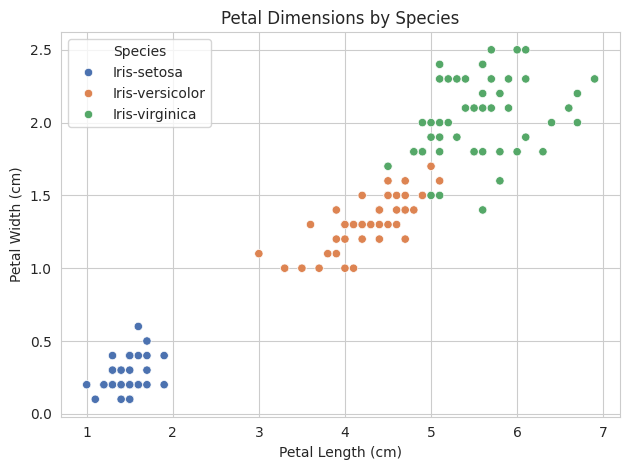

In [3]:
sns.scatterplot(
    data=df,
    x="PetalLengthCm",
    y="PetalWidthCm",
    hue="Species",
    palette="deep",
)
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Dimensions by Species")
plt.tight_layout()
plt.show()


In [4]:
encoder = LabelEncoder()
df["SpeciesId"] = encoder.fit_transform(df["Species"])
class_names = encoder.classes_
df[["Species", "SpeciesId"]].drop_duplicates().reset_index(drop=True)


,Species,SpeciesId
0,Iris-setosa,0
1,Iris-versicolor,1
2,Iris-virginica,2


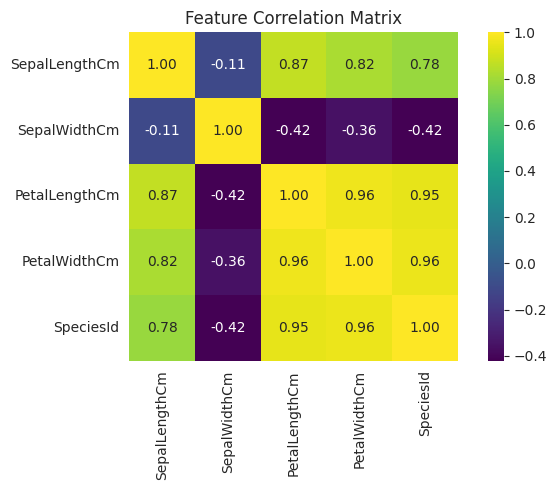

In [5]:
feature_cols = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]

corr = df[feature_cols + ["SpeciesId"]].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()


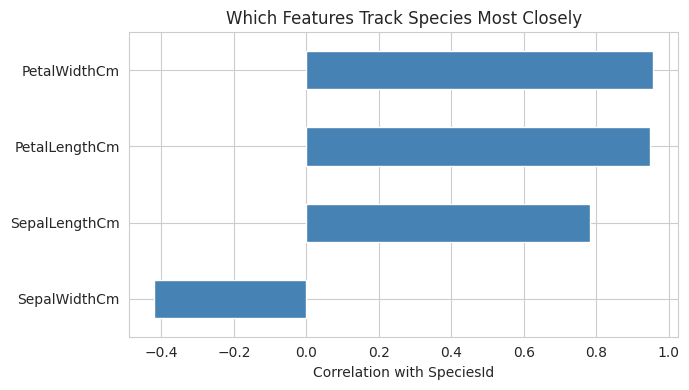

In [6]:
species_corr = corr["SpeciesId"].drop("SpeciesId").sort_values()

plt.figure(figsize=(7, 4))
species_corr.plot(kind="barh", color="steelblue")
plt.xlabel("Correlation with SpeciesId")
plt.title("Which Features Track Species Most Closely")
plt.tight_layout()
plt.show()


## 3. Train / test split and scaling

In [7]:
X = df[feature_cols].values
y = df["SpeciesId"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=7, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape, X_test_scaled.shape


((112, 4), (38, 4))

## 4. The softmax classifier, built from scratch

- Weights start near zero — the model has no prior knowledge.
- Every epoch: forward pass → compute loss → compute gradients → update weights.
- Uses **mini-batch gradient descent with momentum** and a small **L2 penalty**
  (helps generalization, discourages any single feature from dominating).
- `history` records the loss and accuracy at every epoch so we can literally
  watch it learn.


In [8]:
class MulticlassSoftmaxClassifier:
    """
    Multinomial logistic regression trained with mini-batch gradient
    descent + momentum, plus L2 weight decay. Learns weights and biases
    directly from data — nothing here is precomputed or hardcoded.
    """

    def __init__(self, lr=0.05, epochs=2000, batch_size=16, momentum=0.9,
                 l2_penalty=0.001, random_state=42):
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.momentum = momentum
        self.l2_penalty = l2_penalty
        self.rng = np.random.default_rng(random_state)
        self.weights = None
        self.bias = None
        self.history = {"loss": [], "train_acc": []}

    @staticmethod
    def _softmax(logits):
        shifted = logits - logits.max(axis=1, keepdims=True)
        exp_scores = np.exp(shifted)
        return exp_scores / exp_scores.sum(axis=1, keepdims=True)

    @staticmethod
    def _to_one_hot(labels, num_classes):
        encoded = np.zeros((labels.size, num_classes))
        encoded[np.arange(labels.size), labels] = 1.0
        return encoded

    def _forward(self, X):
        return self._softmax(X @ self.weights + self.bias)

    def fit(self, X, y, verbose_every=200):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        # start from small random weights -- the model knows nothing yet
        self.weights = self.rng.normal(0, 0.01, size=(n_features, n_classes))
        self.bias = np.zeros(n_classes)
        velocity_w = np.zeros_like(self.weights)
        velocity_b = np.zeros_like(self.bias)

        y_onehot = self._to_one_hot(y, n_classes)

        for epoch in range(self.epochs):
            perm = self.rng.permutation(n_samples)
            X_shuffled, y_shuffled = X[perm], y_onehot[perm]

            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_shuffled[start:end]
                m = X_batch.shape[0]

                probs = self._forward(X_batch)
                grad_logits = probs - y_batch

                grad_w = (X_batch.T @ grad_logits) / m + self.l2_penalty * self.weights
                grad_b = grad_logits.mean(axis=0)

                velocity_w = self.momentum * velocity_w - self.lr * grad_w
                velocity_b = self.momentum * velocity_b - self.lr * grad_b

                self.weights += velocity_w
                self.bias += velocity_b

            full_probs = self._forward(X)
            epoch_loss = -np.mean(np.sum(y_onehot * np.log(full_probs + 1e-12), axis=1))
            epoch_loss += (self.l2_penalty / 2) * np.sum(self.weights ** 2)
            epoch_preds = np.argmax(full_probs, axis=1)
            epoch_acc = np.mean(epoch_preds == y)

            self.history["loss"].append(epoch_loss)
            self.history["train_acc"].append(epoch_acc)

            if verbose_every and epoch % verbose_every == 0:
                print(f"epoch {epoch:4d}  loss={epoch_loss:.4f}  train_acc={epoch_acc:.4f}")

        return self

    def predict_proba(self, X):
        return self._forward(X)

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)


## 5. Train the model\n\nWatch the printed loss fall and accuracy climb — this is the model actually fitting the data epoch by epoch.

In [9]:
clf = MulticlassSoftmaxClassifier(
    lr=0.05,
    epochs=2000,
    batch_size=16,
    momentum=0.9,
    l2_penalty=0.001,
    random_state=42,
)
clf.fit(X_train_scaled, y_train, verbose_every=200)


epoch    0  loss=0.5383  train_acc=0.8036
epoch  200  loss=0.1035  train_acc=0.9821
epoch  400  loss=0.1027  train_acc=0.9821
epoch  600  loss=0.1027  train_acc=0.9821
epoch  800  loss=0.1026  train_acc=0.9821
epoch 1000  loss=0.1027  train_acc=0.9821
epoch 1200  loss=0.1027  train_acc=0.9821
epoch 1400  loss=0.1026  train_acc=0.9821
epoch 1600  loss=0.1026  train_acc=0.9821
epoch 1800  loss=0.1026  train_acc=0.9821


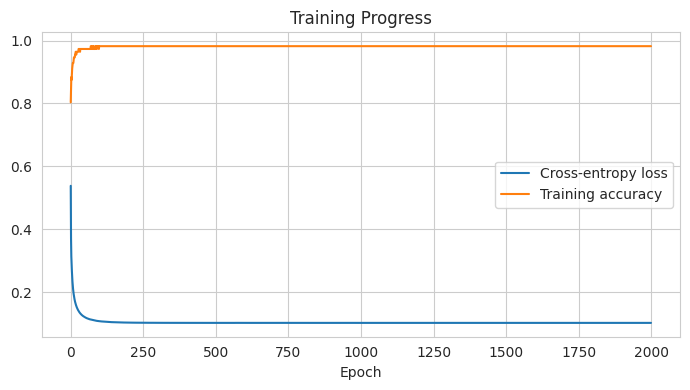

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(clf.history["loss"], label="Cross-entropy loss")
plt.plot(clf.history["train_acc"], label="Training accuracy")
plt.xlabel("Epoch")
plt.title("Training Progress")
plt.legend()
plt.tight_layout()
plt.show()


## 6. Evaluate on held-out test data

In [11]:
y_pred = clf.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")
print(classification_report(y_test, y_pred, target_names=class_names))


Test Accuracy: 0.9737

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        13
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.92      1.00      0.96        12

       accuracy                           0.97        38
      macro avg       0.97      0.97      0.97        38
   weighted avg       0.98      0.97      0.97        38



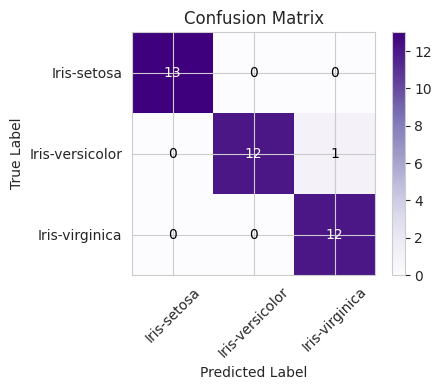

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Purples")
plt.colorbar()
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                  color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.tight_layout()
plt.show()


## Notes

- The model's weights (`clf.weights`, `clf.bias`) are entirely the product of the
  training loop above — try changing `random_state` in the weight initialization
  and you'll see the loss curve start from a different random point.
- To confirm it's really learning and not memorizing, try shrinking `epochs` to
  something small (e.g. 5) and re-running — accuracy should drop noticeably,
  since it hasn't had time to converge yet.
